# Homework 6: Convolutional Neural Networks for Image Recognition
**Name:** Aragya Goyal | **Student ID:** 4541458 | **D value:** 58

In [7]:
# Import Packages
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import sklearn

# Define Globals
D = 58

## Question 1: From HW6 to CNNs - Conceptual Foundations

### Part A: Connecting to HW6
**Text Response:**

TODO

### Part B: How CNNs Solve the Problem - A Detailed Illustration
**Text Response:**
1. TODO
2. TODO
3. TODO

## Question 2: Building and Training a CNN
### Part A: Data Preparation

Original X shape: (15000, 1024)
Original y shape: (15000,)
Reshaped X_train shape: (13000, 32, 32, 1)
Reshaped X_test shape: (2000, 32, 32, 1)
Original y_train shape: (13000,)
Original y_test shape: (2000,)
Maximum pixel value: 1.0
y_train_vec shape: (13000, 3)
y_test_vec shape: (2000, 3)


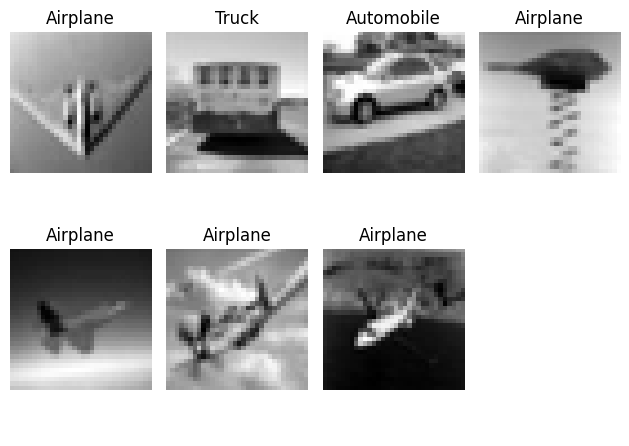

In [2]:
# Load Dataset
data = scipy.io.loadmat('./input/ps6_vehicles.mat')

# Define X and y
X = data['X']
y = data['y_labels'].flatten()

# Report Dimensions
print(f"Original X shape: {X.shape}")
print(f"Original y shape: {y.shape}")

# Set random seed
np.random.seed(D+1)

# Perform the split
indices = np.random.permutation(X.shape[0])
split = 13000

X_train = X[indices[:split]]
y_train = y[indices[:split]]
X_test = X[indices[split:]]
y_test = y[indices[split:]]

# Reshape to images
X_train = X_train.reshape(-1, 32, 32, 1)
X_test = X_test.reshape(-1, 32, 32, 1)

# Display reshaped dimensions
print(f"Reshaped X_train shape: {X_train.shape}")
print(f"Reshaped X_test shape: {X_test.shape}")
print(f"Original y_train shape: {y_train.shape}")
print(f"Original y_test shape: {y_test.shape}")

# Normalize pixel values
max_val = X_train.max()
print(f"Maximum pixel value: {max_val}")
X_train = X_train / max_val
X_test = X_test / max_val

# One-hot encode labels
y_train_vec = tf.keras.utils.to_categorical(y_train - 1, num_classes=3)
y_test_vec = tf.keras.utils.to_categorical(y_test - 1, num_classes=3)
print(f"y_train_vec shape: {y_train_vec.shape}")
print(f"y_test_vec shape: {y_test_vec.shape}")

# Display training images in grid
num_images = 4 + (D % 5)
rand_indices = np.random.choice(X_train.shape[0], num_images, replace=False)
class_names = {1: 'Airplane', 2: 'Automobile', 3: 'Truck'}

cols = 4
rows = int(np.ceil(num_images / cols))
fig, axes = plt.subplots(rows, cols)
for i, ax, in enumerate(axes.flatten()):
    if i < num_images:
        ax.imshow(X_train[rand_indices[i]].reshape(32, 32).T, cmap='gray')
        ax.set_title(class_names[y_train[rand_indices[i]]])
    ax.axis('off')
plt.tight_layout()
plt.show()

**Text Response:**

TODO

### Part B: CNN Architecture Design

In [3]:
# Compute personalized values
conv1_filters = 8 + (D % 8)
conv2_filters = 16 + (D % 16)
dense_units = 32 + (D % 32)

# Build the model
model = Sequential([
    Conv2D(conv1_filters, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(conv2_filters, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(dense_units, activation='relu'),
    Dense(3, activation='softmax')
])

# Print model summary
model.summary()


c:\Users\agoya\Documents\AllCode\1395_MachineLearning\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 26)     │         2,366 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 26)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1664)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 58)             │        96,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           177 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,213 (387.55 KB)

 Trainable params: 99,213 (387.55 KB)

 Non-trainable params: 0 (0.00 B)

**Text Response:**

TODO

### Part C: Training

Batch size: 122
Epochs: 14
Epoch 1/14
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5994 - loss: 0.8536 - val_accuracy: 0.6515 - val_loss: 0.7473
Epoch 2/14
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6737 - loss: 0.7250 - val_accuracy: 0.6815 - val_loss: 0.6798
Epoch 3/14
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7068 - loss: 0.6692 - val_accuracy: 0.7100 - val_loss: 0.6404
Epoch 4/14
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7511 - loss: 0.5982 - val_accuracy: 0.7677 - val_loss: 0.5567
Epoch 5/14
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7752 - loss: 0.5525 - val_accuracy: 0.7800 - val_loss: 0.5405
Epoch 6/14
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7993 - loss: 0.5013 - val_accuracy: 0.7838 - val_loss: 0.5083
Epoch 7/14
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8132 - loss: 0.4709 - val_accuracy: 0.7892 - val_loss: 0.4968
Epoch 8/14
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8270 - loss: 0.4461 - val_

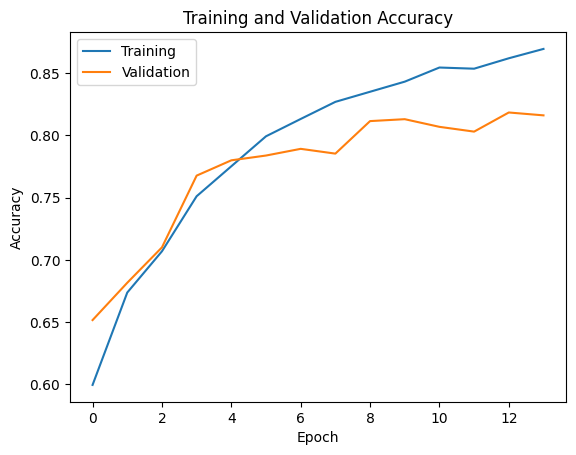

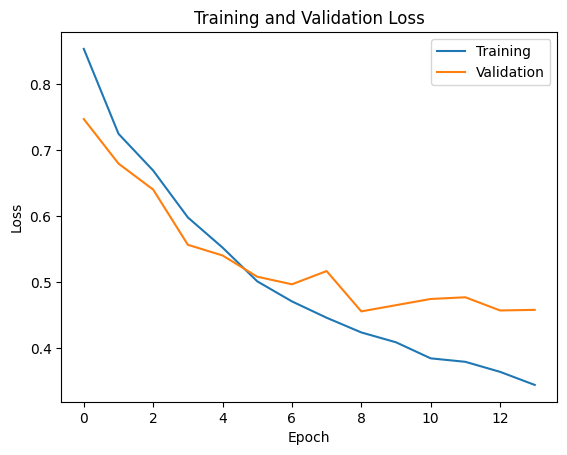

Final training accuracy: 86.9572639465332%
Final validation accuracy: 81.61538243293762%


In [4]:
# Compute personalized settings
batch_size = 64 + (D % 64)
epochs = 10 + (D % 6)

# Report batch size and num epochs
print(f"Batch size: {batch_size}")
print(f"Epochs: {epochs}")

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train_vec, batch_size=batch_size, epochs=epochs, validation_split=0.1)

# Plot accuracy
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Report final values
print(f"Final training accuracy: {history.history['accuracy'][-1]*100}%")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]*100}%")

**Text Response:**
TODO

### Part D: Evaluation and Comparison with HW6

In [ ]:
# Get test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test_vec)
print(f"Test accuracy: {test_acc*100}%")

# Compute and display confusion matrix
cm = sklearn.metrics.confusion_matrix()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8235 - loss: 0.4455
Test accuracy: 82.34999775886536%
